# Imports

In [1]:
import io
import logging
import os
import re
import zipfile
from multiprocessing import Pool, cpu_count
from pathlib import Path
from pprint import pp, pprint
from typing import List, Tuple
import gc
from matplotlib import pyplot as plt

import polars as pl
from tqdm import tqdm
from pymsis import msis
from pymsis.utils import get_f107_ap
import logging

logging.basicConfig(level=logging.INFO)

# Decoder

In [2]:
from decode import *

inputpath: str = "data/original/tudelft"
outpath: str = "data/decoded/tudelft"
missions_list: List[str] = os.listdir(inputpath)

tmp_decode_mainfest_df = (
    pl.read_csv(outpath + "/tmp_decode_manifest.csv")
    if os.path.exists(outpath + "/tmp_decode_manifest.csv")
    else None
)
done_files = (
    tmp_decode_mainfest_df["source_path"].to_list()
    if tmp_decode_mainfest_df is not None
    else []
)

arg_list = [
    (
        mission,
        inputpath + "/" + mission + "/" + filepath,
        outpath + "/" + mission + "/tmp/" + filepath.replace(".zip", ".parquet"),
        outpath + "/tmp_decode_manifest.csv",
    )
    for mission in missions_list
    for filepath in os.listdir(inputpath + "/" + mission)
    if filepath.lower().endswith(".zip")
    and inputpath + "/" + mission + "/" + filepath not in done_files
]
with Pool() as pool:
    results = [
        el
        for el in list(
            tqdm(
                pool.imap(
                    decode_tudelft_single_worker,
                    arg_list,
                ),
                total=len(arg_list),
            )
        )
        if el is not None
    ]
# one at a time for debugging
# results = [
#     decode_tudelft_single(*args) for args in tqdm(arg_list, total=len(arg_list))
# ]

if len(results) == 0:
    if tmp_decode_mainfest_df is None:
        logging.warning("No valid files were decoded.")
    else:
        logging.info("All files were already decoded. Skipping decoding step.")
if len(results) < len(arg_list):
    logging.warning(
        "%d out of %d files were decoded successfully.",
        len(results),
        len(arg_list),
    )
results = results + (
    [
        (row[0], row[1], row[2], row[3])
        for row in tmp_decode_mainfest_df.select(
            ["mission", "mission_code", "parquet_path", "source_path"]
        ).iter_rows()
    ]
    if tmp_decode_mainfest_df is not None
    else []
)
# group by mission code
mission_temp_paths = {}
for mission, mission_code, parquet_path, source_path in results:
    if mission_code not in mission_temp_paths:
        mission_temp_paths[mission_code] = {
            "mission": mission,
            "parquet_paths": [],
        }
    mission_temp_paths[mission_code]["parquet_paths"].append(parquet_path)
decoded_manifest_path = outpath + "/decoded_manifest.csv"
if os.path.exists(decoded_manifest_path):
    decoded_manifest_sources = pl.read_csv(decoded_manifest_path)[
        "mission_code"
    ].to_list()
else:
    decoded_manifest_sources = []

merge_args = [
    (
        mission_code,
        mission_temp_paths[mission_code]["parquet_paths"],
        outpath
        + "/"
        + mission_temp_paths[mission_code]["mission"]
        + "/"
        + mission_code
        + "_merged.parquet",
        decoded_manifest_path,
    )
    for mission_code in mission_temp_paths
    if mission_code not in decoded_manifest_sources
]


with Pool() as pool:
    pool.map(merge_parquets_single_worker, merge_args)
# one at a time for debugging
# for args in tqdm(merge_args, total=len(merge_args)):
#     merge_parquets_single_worker(args)

gc.collect()

0it [00:00, ?it/s]
INFO:root:All files were already decoded. Skipping decoding step.


778

# Generate MSIS data

In [3]:
from msis_generator import compute_msis_density_parallel

decoded_files = [
    (file, n)
    for n, file in enumerate(
        pl.read_csv(outpath + "/decoded_manifest.csv")["parquet_path"].to_list()
    )
]
manifest_path = outpath.replace("decoded", "msis") + "/msis_completed_manifest.csv"

files_with_msis = compute_msis_density_parallel(
    decoded_files,
    batch_size=5_000_000,
    processes=max(cpu_count() - 1, 1),
    inner_threads=16,
    show_progress=True,
    manifest_path=manifest_path,
    resume=True,
)
# for file in tqdm(decoded_files, total=len(decoded_files)):
#     compute_msis_density_parallel(file)

Skipping 8 already-completed files
Nothing to do. All files are already complete.


# Compute errors

In [ ]:
pp(files_with_msis)
analyzed_files = [
    str(file["output_file"])
    .replace("msis", "analyzed")
    .replace("decoded", "analyzed")
    .replace("merged_msis", "analyzed")
    for file in files_with_msis
    if os.path.exists(file["output_file"])
]


[{'status': 'skipped',
  'source_file': (('data/decoded/tudelft/goce/GO_merged.parquet', 0),
                  'manifest',
                  PosixPath('data/msis/tudelft/goce/GO_msis.parquet')),
  'output_file': PosixPath('data/msis/tudelft/goce/GO_msis.parquet')},
 {'status': 'skipped',
  'source_file': (('data/decoded/tudelft/swarm/SC_merged.parquet', 1),
                  'manifest',
                  PosixPath('data/msis/tudelft/swarm/SC_msis.parquet')),
  'output_file': PosixPath('data/msis/tudelft/swarm/SC_msis.parquet')},
 {'status': 'skipped',
  'source_file': (('data/decoded/tudelft/swarm/SA_merged.parquet', 2),
                  'manifest',
                  PosixPath('data/msis/tudelft/swarm/SA_msis.parquet')),
  'output_file': PosixPath('data/msis/tudelft/swarm/SA_msis.parquet')},
 {'status': 'skipped',
  'source_file': (('data/decoded/tudelft/swarm/SB_merged.parquet', 3),
                  'manifest',
                  PosixPath('data/msis/tudelft/swarm/SB_msis.parquet')),

In [5]:
import numpy as np

obs_col = "Density (kg/m^3)"
msis_cols = ["msis_density_0", "msis_density_2.0", "msis_density_2.1"]
for source_file, output_file in tqdm(
    list(
        zip(
            [file["output_file"] for file in files_with_msis],
            analyzed_files,
        )
    )
):
    if os.path.exists(output_file):
        continue
    df = pl.read_parquet(source_file)
    # for each of the msis columns compute:
    # - the ln(Density(kg/m^3)/msis_density) and store it in a new column called ln_density_ratio_VERSION
    # - the relative error (Density(kg/m^3) - msis_density)/msis_density and store it in a new column called relative_error_VERSION
    for msis_col in msis_cols:
        version = msis_col.replace("msis_density_", "")
        df = df.with_columns(
            ((pl.col(msis_col) / pl.col(obs_col)).log() / np.log(np.e)).alias(
                f"ln_density_ratio_{version}"
            ),
            ((pl.col(obs_col) - pl.col(msis_col)) / pl.col(msis_col)).alias(
                f"relative_error_{version}"
            ),
        )
        # drop nans
        df = df.filter(
            pl.col(f"ln_density_ratio_{version}").is_finite()
            & pl.col(f"relative_error_{version}").is_finite()
        )
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    df.write_parquet(output_file)
    del df

100%|██████████| 8/8 [00:00<00:00, 18631.00it/s]


# Display data

100%|██████████| 8/8 [00:15<00:00,  1.88s/it]
/tmp/ipykernel_111141/2516125078.py:83: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


148454

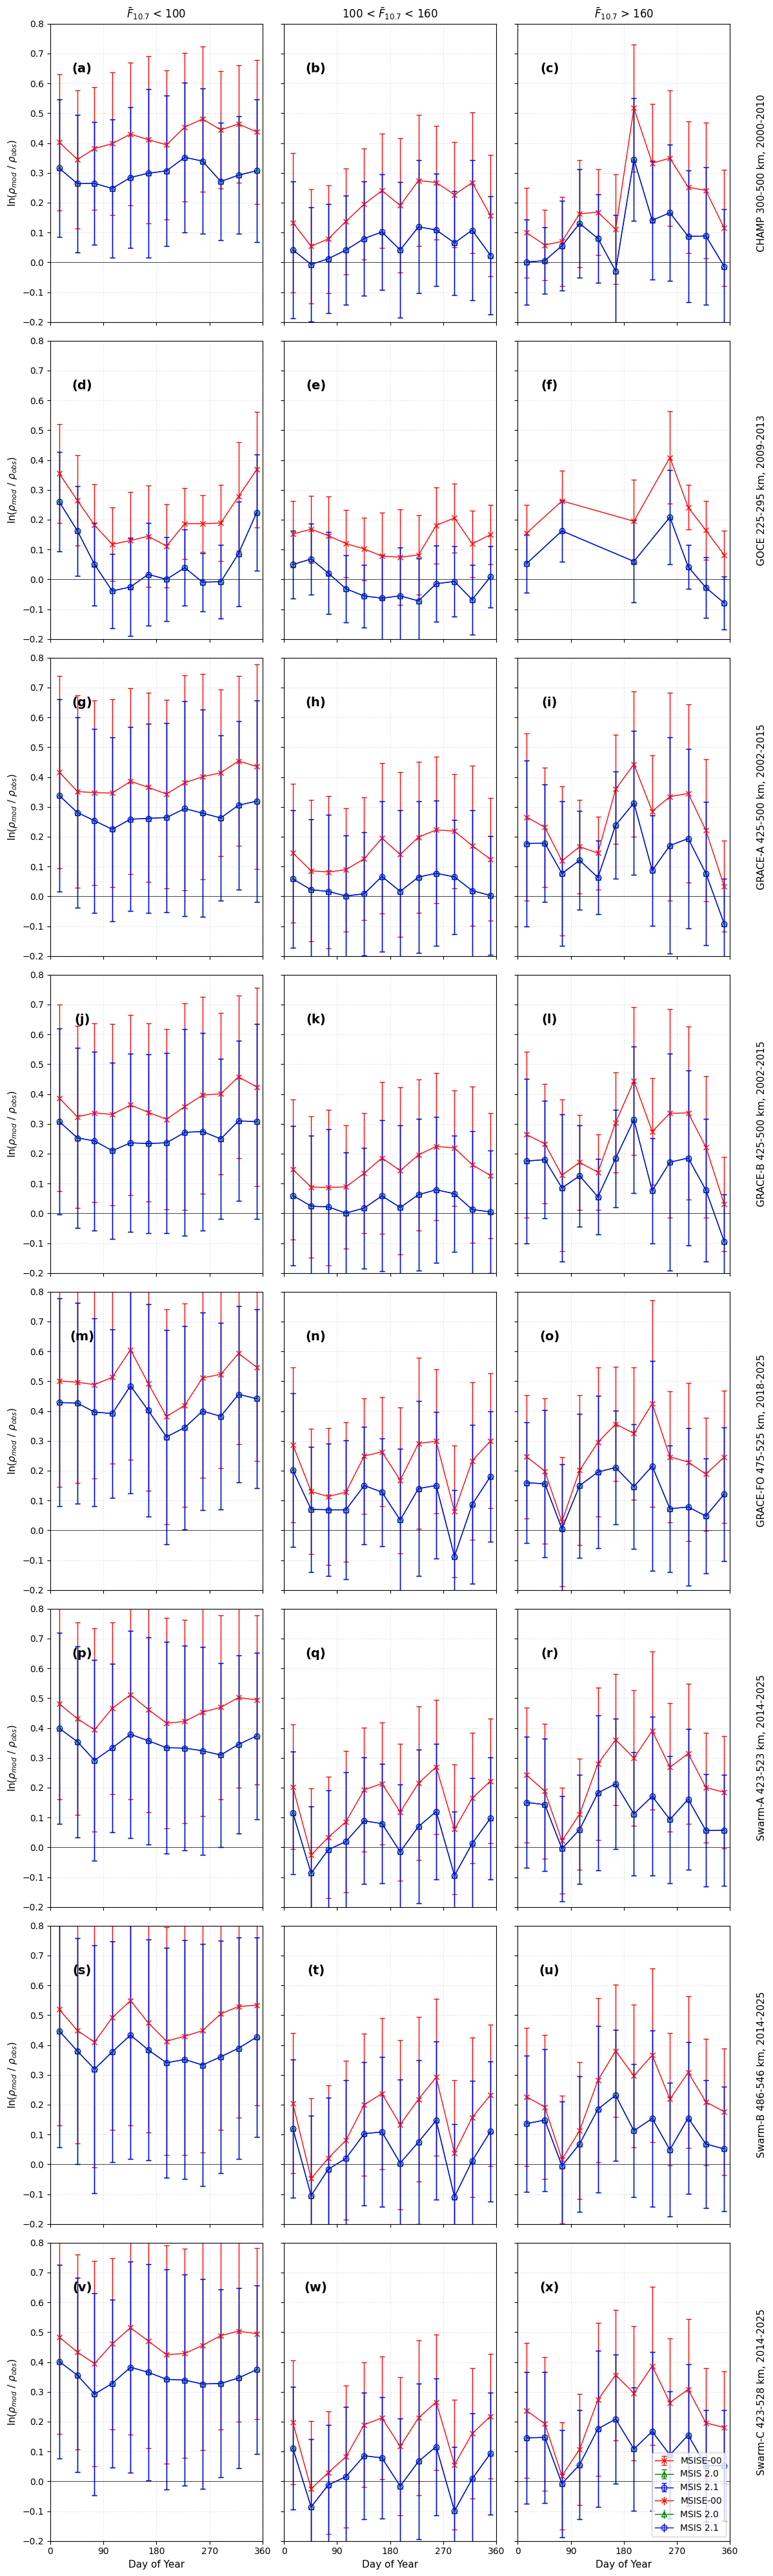

In [ ]:
from figure_19_generator import create_figure_19

mission_data = {
    "GO": {
        "name": "GOCE",
        "altitude_range": (225, 300),
    },
    "CH": {
        "name": "CHAMP",
        "altitude_range": (300, 500),
    },
    "GA": {
        "name": "GRACE-A",
        "altitude_range": (425, 500),
    },
    "GB": {
        "name": "GRACE-B",
        "altitude_range": (425, 500),
    },
    "GC": {
        "name": "GRACE-FO",
        "altitude_range": (475, 525),
    },
    "SA": {
        "name": "Swarm-A",
        "altitude_range": (425, 500),
    },
    "SB": {
        "name": "Swarm-B",
        "altitude_range": (500, 525),
    },
    "SC": {
        "name": "Swarm-C",
        "altitude_range": (450, 525),
    },
}
sorted_analyzed_files = sorted(
    analyzed_files,
    key=lambda x: mission_data.get(
        x.split("/")[-1].split("_")[0],
        x.split("/")[-1].split("_")[0],
    )["name"],
)

mission_names = [
    mission_data[file.split("/")[-1].split("_")[0]]["name"]
    for file in sorted_analyzed_files
]
altitude_ranges = [
    mission_data[file.split("/")[-1].split("_")[0]]["altitude_range"]
    for file in sorted_analyzed_files
]
fig = create_figure_19(
    dfs=[
        pl.read_parquet(file).filter(
            (
                (pl.col("Altitude (m)") / 1000).is_between(*altitude_range)
                & (pl.col("Anomalus Density (kg/m^3)") == 0)
                if "Swarm" not in mission_name
                else pl.lit(True)
                & (
                    pl.col("Anomalus Density Mean (kg/m^3)") == 0
                    if "Swarm" not in mission_name
                    else pl.lit(True)
                )
            )
            & (
                (pl.col("Degraded Flag Thrusters") == 0)
                if mission_name == "GOCE"
                else pl.lit(True)
            )
        )
        for file, altitude_range, mission_name in tqdm(
            zip(sorted_analyzed_files, altitude_ranges, mission_names),
            total=len(sorted_analyzed_files),
        )
    ],
    mission_names=mission_names,
    msis_00_col="ln_density_ratio_0",
    msis_20_col="ln_density_ratio_2.0",
    msis_21_col="ln_density_ratio_2.1",
)
fig.savefig("figure_19.png", dpi=600, bbox_inches="tight")
fig.show()
gc.collect()

In [10]:
df = pl.read_parquet(analyzed_files[0])

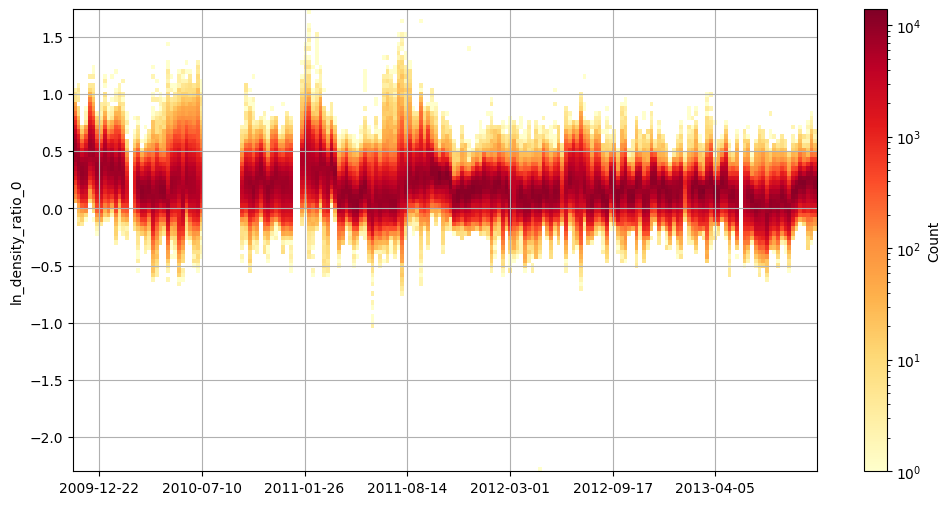

In [16]:
import matplotlib
import matplotlib.dates as mdates

plt.figure(figsize=(12, 6))
# Convert timestamp to matplotlib's date format (days since epoch)
x = mdates.date2num(df["timestamp"])
plt.hist2d(x, df["ln_density_ratio_0"], bins=(200, 100), 
           cmap="YlOrRd", norm=matplotlib.colors.LogNorm())
plt.colorbar(label="Count")
plt.ylabel("ln_density_ratio_0")
plt.grid(True)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # format as dates
plt.show()